Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

Dataset Shape

In [2]:
print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

train_df.head()

Train Shape : (2000, 8)
Test Shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


Missing Values

In [3]:
train_df.isnull().sum()

test_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Duplicate Questions

In [5]:
print("Duplicate prompts:",
      train_df["prompt"].duplicated().sum())

Duplicate prompts: 242


Answer Distribution

In [6]:
train_df["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

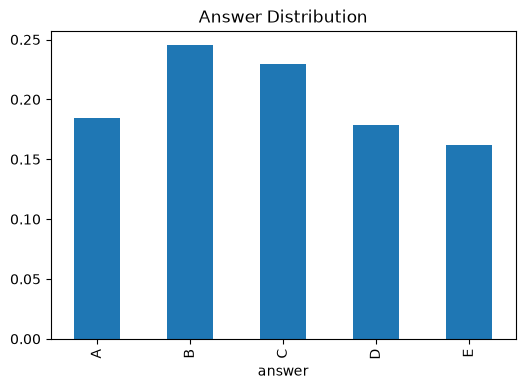

In [ ]:
train_df["answer"].value_counts(normalize=True).sort_index().plot(
    kind="bar",
    figsize=(6,4),
)

plt.title("Answer Distribution")
plt.show()

In [12]:
train_df["answer"].value_counts(normalize=True)

answer
B    0.2450
C    0.2295
A    0.1845
D    0.1790
E    0.1620
Name: proportion, dtype: float64

Prompt Length Distribution

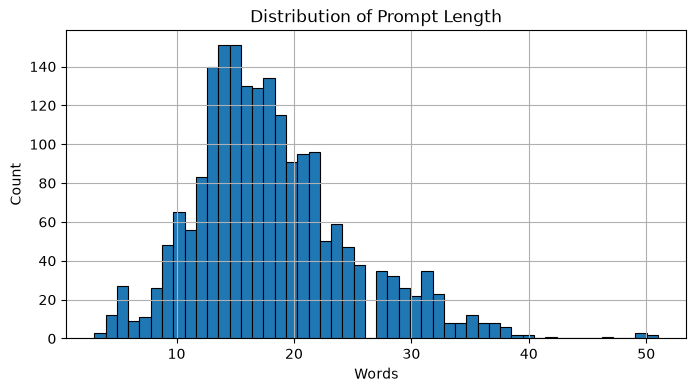

In [ ]:
import matplotlib.pyplot as plt

train_df["prompt_length"] = train_df["prompt"].str.split().apply(len)

plt.figure(figsize=(8,4))

train_df["prompt_length"].hist(
    bins=50,
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel("Words")
plt.ylabel("Count")
plt.title("Distribution of Prompt Length")

plt.show()

Word Count Distribution

In [11]:
train_df["prompt_words"] = train_df["prompt"].str.split().apply(len)

train_df["prompt_words"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_words, dtype: float64

In [ ]:
counter = Counter()

for text in train_df["prompt"]:
    counter.update(text.lower().split())

len(counter)

931

In [16]:
counter.most_common(20)

[('the', 5528),
 ('is', 1986),
 ('what', 1809),
 ('of', 1514),
 ('correct', 893),
 ('following', 746),
 ('in', 714),
 ('answer:', 608),
 ('option:', 608),
 ('and', 448),
 ('from', 442),
 ('a', 425),
 ('on', 424),
 ('which', 399),
 ('based', 397),
 ('among', 388),
 ('listed', 388),
 ('options.', 388),
 ('given', 376),
 ('context.', 376)]